In [81]:
import pandas as pd 
import numpy as np 


In [82]:
df= pd.read_csv(r'CKD_dataset.csv')
df.head()

,Sr. No,Sex,Age,Haemoglobin,Hematocrit,Lymphocytes,MCH,MCHC,MCV,Monocytes,...,Platelet Count,Polymorphs,RBC Count,RDW SD,WBC Count,Eosinophils,Creatinine,Urea,GFR,Target
0,1,0,49,9.3,25.0,12,28.0,36.0,78.0,3,...,163,83,3.2,16.3,7.7,2,12.2,239.0,3.29,1
1,2,0,65,12.1,36.9,14,31.0,36.0,96.0,7,...,131,76,3.8,53.0,6.4,3,9.0,113.0,4.41,1
2,3,1,27,13.4,53.2,27,34.0,33.0,106.0,9,...,119,60,3.8,19.0,5.5,4,9.9,96.0,6.36,1
3,4,1,22,11.0,32.7,28,33.0,34.0,99.0,4,...,148,66,3.3,47.0,5.1,2,13.4,136.0,4.68,1
4,5,0,45,11.0,47.0,30,24.0,31.0,83.0,4,...,204,64,3.6,21.0,10.3,2,11.0,160.0,3.77,1


In [83]:
df.columns = df.columns.str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sr. No          398 non-null    int64  
 1   Sex             398 non-null    int64  
 2   Age             398 non-null    int64  
 3   Haemoglobin     398 non-null    float64
 4   Hematocrit      398 non-null    float64
 5   Lymphocytes     398 non-null    int64  
 6   MCH             398 non-null    float64
 7   MCHC            398 non-null    float64
 8   MCV             398 non-null    float64
 9   Monocytes       398 non-null    int64  
 10  MPV             398 non-null    float64
 11  PCT             398 non-null    float64
 12  PDW             398 non-null    float64
 13  Platelet Count  398 non-null    int64  
 14  Polymorphs      398 non-null    int64  
 15  RBC Count       398 non-null    float64
 16  RDW SD          398 non-null    float64
 17  WBC Count       398 non-null    flo

In [84]:
df[df['GFR'].isnull()]

,Sr. No,Sex,Age,Haemoglobin,Hematocrit,Lymphocytes,MCH,MCHC,MCV,Monocytes,...,Platelet Count,Polymorphs,RBC Count,RDW SD,WBC Count,Eosinophils,Creatinine,Urea,GFR,Target
226,227,1,48,9.7,28.9,20,30.0,33.0,91.0,8,...,201,68,3.1,44.0,7.1,4,NaN,207.0,NaN,1
315,316,1,59,14.0,44.0,23,31.0,34.0,91.0,3,...,228,73,4.9,14.2,8.2,1,0.0,24.0,NaN,0


In [85]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 0 to 397
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sr. No          391 non-null    int64  
 1   Sex             391 non-null    int64  
 2   Age             391 non-null    int64  
 3   Haemoglobin     391 non-null    float64
 4   Hematocrit      391 non-null    float64
 5   Lymphocytes     391 non-null    int64  
 6   MCH             391 non-null    float64
 7   MCHC            391 non-null    float64
 8   MCV             391 non-null    float64
 9   Monocytes       391 non-null    int64  
 10  MPV             391 non-null    float64
 11  PCT             391 non-null    float64
 12  PDW             391 non-null    float64
 13  Platelet Count  391 non-null    int64  
 14  Polymorphs      391 non-null    int64  
 15  RBC Count       391 non-null    float64
 16  RDW SD          391 non-null    float64
 17  WBC Count       391 non-null    float64


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['Target','Sr. No'])   # all columns except the target
y = df['Target']                  # target column

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test, 80% train
    random_state=42,    # reproducibility
    stratify=y          # keeps class distribution balanced
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (312, 21) (312,)
Test shape: (79, 21) (79,)


In [87]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [88]:
model=RandomForestClassifier()


In [89]:
model.fit(X_train_scaled,y_train)
pred= model.predict(X_test_scaled)

In [90]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,pred)
accuracy

0.9493670886075949

In [91]:
# Filter the dataframe
new_data = df[(df["GFR"] == 5.83) & (df["Creatinine"] == 9.1)]

print("Filtered Data:")
print(new_data)

# Drop extra columns so it matches training features
row_features = new_data.drop(columns=['Sr. No', 'Target'])

# Generate prediction
prediction = model.predict(row_features)

print("🧠 Predicted CKD Stage for the input data:", prediction)


Filtered Data:
    Sr. No  Sex  Age  Haemoglobin  Hematocrit  Lymphocytes   MCH  MCHC   MCV  \
50      51    1   67          9.8        29.0           20  27.0  33.0  80.0   

    Monocytes  ...  Platelet Count  Polymorphs  RBC Count  RDW SD  WBC Count  \
50          7  ...             175          71        3.6    40.0        6.9   

    Eosinophils  Creatinine   Urea   GFR  Target  
50            3         9.1  122.0  5.83       1  

[1 rows x 23 columns]
🧠 Predicted CKD Stage for the input data: [0]


C:\Users\PMLS\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Compute all metrics at once
accuracy  = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall    = recall_score(y_test, pred)
f1        = f1_score(y_test, pred)
auc       = roc_auc_score(y_test, pred)
cm        = confusion_matrix(y_test, pred)

# Print nicely
print("✅ Classification Metrics")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"ROC-AUC    : {auc:.4f}")
print("\nConfusion Matrix:")
print(cm)


✅ Classification Metrics
Accuracy   : 0.9494
Precision  : 0.9574
Recall     : 0.9574
F1-score   : 0.9574
ROC-AUC    : 0.9475

Confusion Matrix:
[[30  2]
 [ 2 45]]


In [93]:
feature_names=X.columns
feature_names

Index(['Sex', 'Age', 'Haemoglobin', 'Hematocrit', 'Lymphocytes', 'MCH', 'MCHC',
       'MCV', 'Monocytes', 'MPV', 'PCT', 'PDW', 'Platelet Count', 'Polymorphs',
       'RBC Count', 'RDW SD', 'WBC Count', 'Eosinophils', 'Creatinine', 'Urea',
       'GFR'],
      dtype='object')

In [94]:
import shap

# Get the first row as a DataFrame
row=row_features
# row = X_test.iloc[[1]]
prediction = model.predict(row)


print("🧠 Predicted CKD Stage for the input data:", prediction)
explainer = shap.TreeExplainer(model)
# explanation = explainer(X_test.iloc[[1]])
explanation = explainer(row)


🧠 Predicted CKD Stage for the input data: [0]


C:\Users\PMLS\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


# For CKD 

In [95]:
input = X_test.iloc[1].to_dict()
input

{'Sex': 0.0,
 'Age': 39.0,
 'Haemoglobin': 12.4,
 'Hematocrit': 38.1,
 'Lymphocytes': 32.0,
 'MCH': 27.0,
 'MCHC': 32.0,
 'MCV': 84.0,
 'Monocytes': 7.0,
 'MPV': 10.0,
 'PCT': 0.21,
 'PDW': 15.0,
 'Platelet Count': 216.0,
 'Polymorphs': 59.0,
 'RBC Count': 4.5,
 'RDW SD': 41.0,
 'WBC Count': 9.5,
 'Eosinophils': 2.0,
 'Creatinine': 10.6,
 'Urea': 132.0,
 'GFR': 4.05}

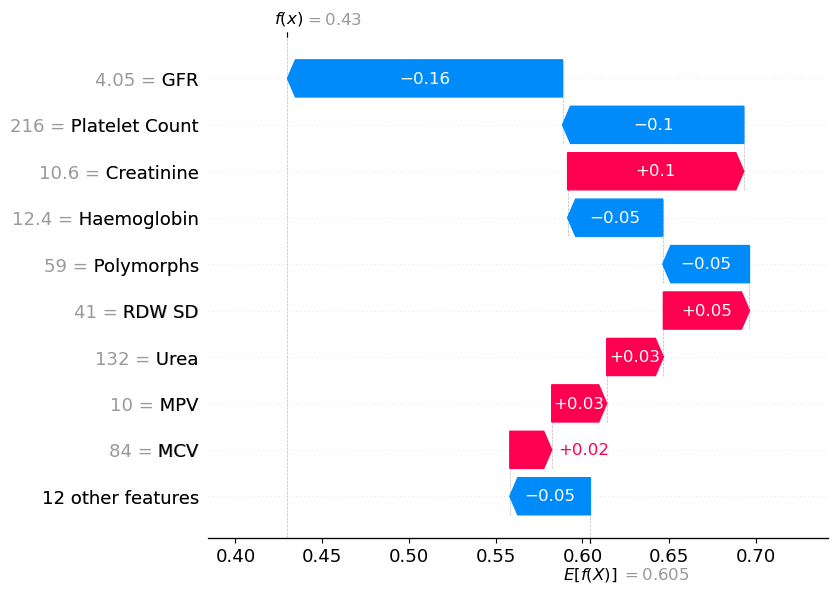

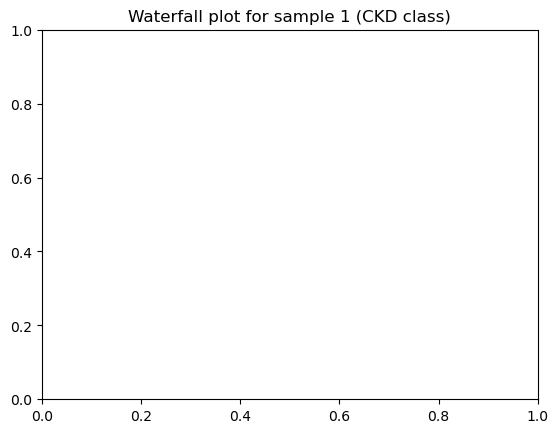

In [99]:
import shap
import matplotlib.pyplot as plt

# --- Step 1: Pick one row from X_test ---
row = X_test.iloc[[1]]   # patient at index 1

# --- Step 2: Create TreeExplainer ---
explainer = shap.TreeExplainer(model)

# --- Step 3: Generate SHAP values for this row ---
shap_values_row = explainer(row)

# --- Step 4: Waterfall plot for CKD class (index 1) ---
shap.plots.waterfall(shap_values_row[0, :, 1])
plt.title("Waterfall plot for sample 1 (CKD class)")
plt.show()


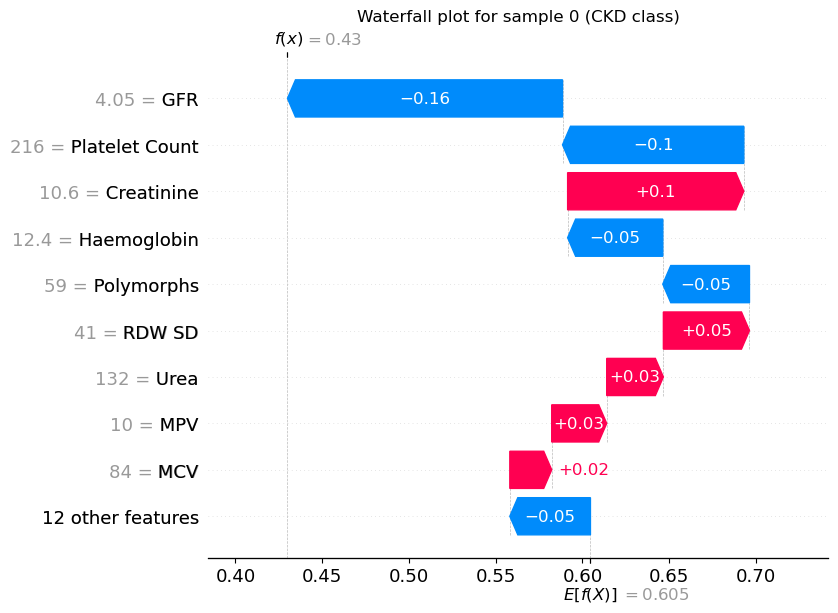

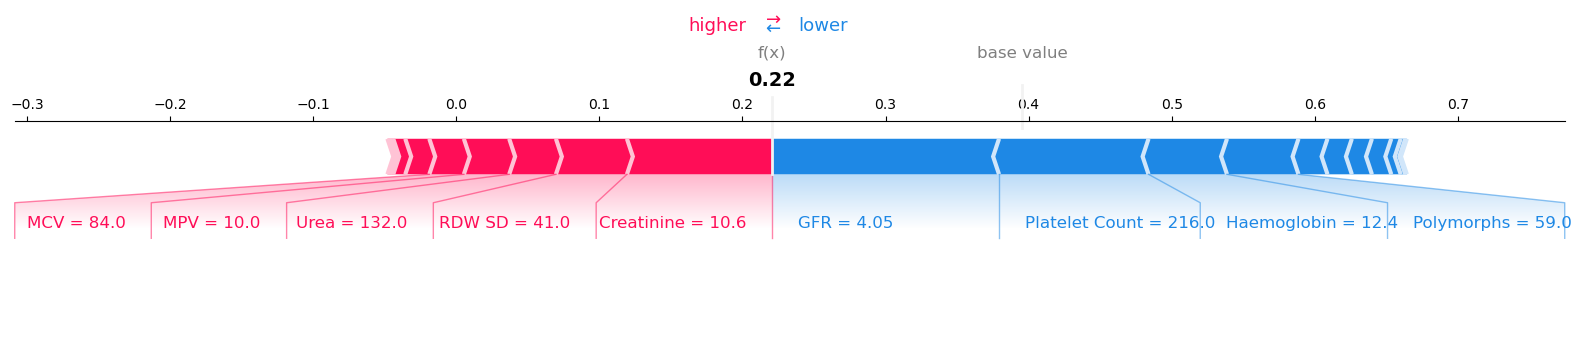

In [96]:
import shap
import matplotlib.pyplot as plt

# --- Step 1: Pick one row from X_test ---
row = X_test.iloc[[1]]   # patient 0

# --- Step 2: Create TreeExplainer ---
explainer = shap.TreeExplainer(model)

# --- Step 3: Generate SHAP values for this row ---
shap_values_row = explainer(row)

# --- Step 4: Waterfall plot for instance 0 ---
shap.plots.waterfall(shap_values_row[0,:,1], show=False)  # class 1 = CKD
plt.title("Waterfall plot for sample 0 (CKD class)")
plt.show()

# --- Step 5: Force plot (raceplot style) for instance 0 ---
shap.force_plot(
    explainer.expected_value[0],        # base value for CKD class
    shap_values_row.values[0,:,1],      # SHAP contributions
    row,                                # feature values
    matplotlib=True                     # render with matplotlib
)

# For Not CKD 

In [97]:
input = X_test.iloc[1].to_dict()
input

{'Sex': 0.0,
 'Age': 39.0,
 'Haemoglobin': 12.4,
 'Hematocrit': 38.1,
 'Lymphocytes': 32.0,
 'MCH': 27.0,
 'MCHC': 32.0,
 'MCV': 84.0,
 'Monocytes': 7.0,
 'MPV': 10.0,
 'PCT': 0.21,
 'PDW': 15.0,
 'Platelet Count': 216.0,
 'Polymorphs': 59.0,
 'RBC Count': 4.5,
 'RDW SD': 41.0,
 'WBC Count': 9.5,
 'Eosinophils': 2.0,
 'Creatinine': 10.6,
 'Urea': 132.0,
 'GFR': 4.05}

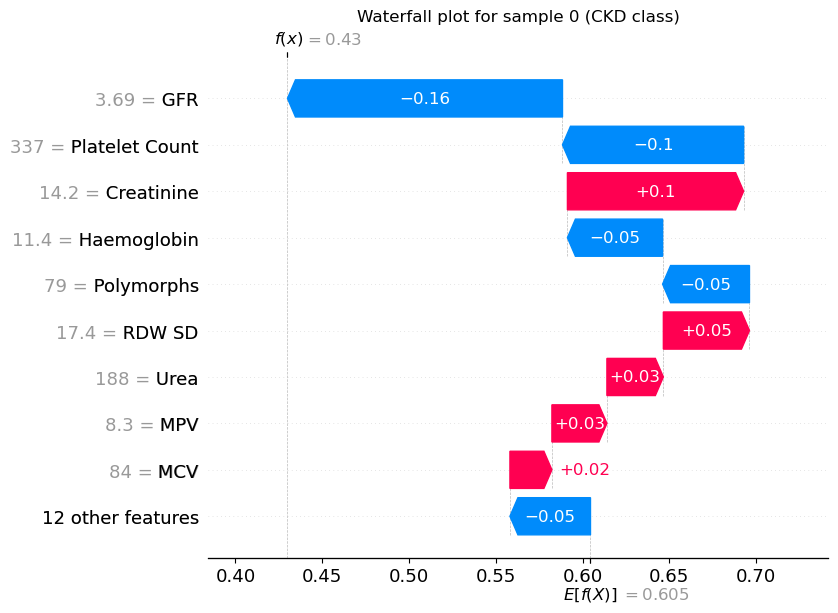

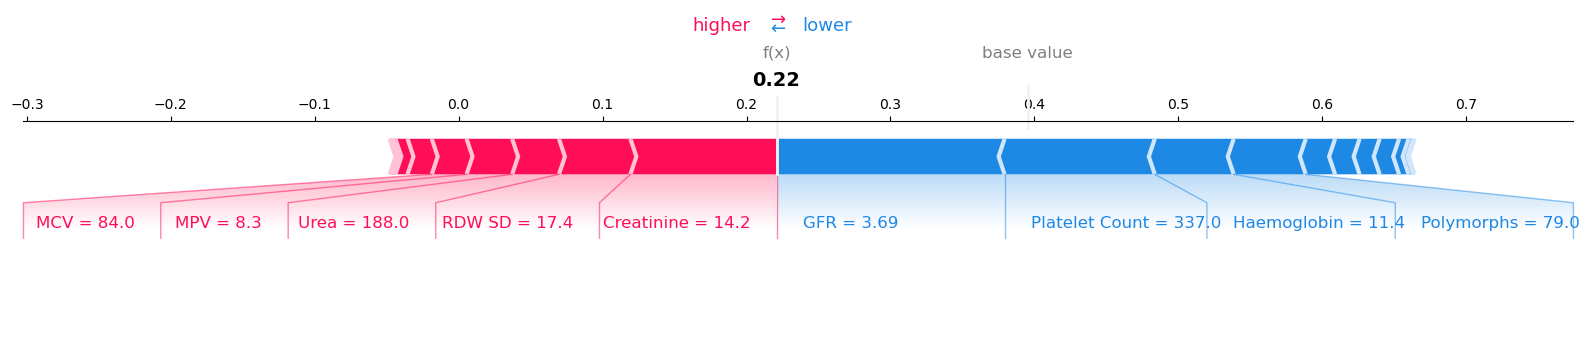

In [98]:
import shap
import matplotlib.pyplot as plt

# --- Step 1: Pick one row from X_test ---
row = X_test.iloc[[2]]   # patient 0

# --- Step 2: Create TreeExplainer ---
explainer = shap.TreeExplainer(model)

# --- Step 3: Generate SHAP values for this row ---
shap_values_row = explainer(row)

# --- Step 4: Waterfall plot for instance 0 ---
shap.plots.waterfall(shap_values_row[0,:,1], show=False)  # class 1 = CKD
plt.title("Waterfall plot for sample 0 (CKD class)")
plt.show()

# --- Step 5: Force plot (raceplot style) for instance 0 ---
shap.force_plot(
    explainer.expected_value[0],        # base value for CKD class
    shap_values_row.values[0,:,1],      # SHAP contributions
    row,                                # feature values
    matplotlib=True                     # render with matplotlib
)

